# Stage 11 — Mars inference

_Pipeline stage 11 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Applying the Earth-trained regime models to Mars

Per regime we recompute Mars embeddings with that regime's CNN, apply its combined
XGBoost, and threshold at the regime's operating point -> a touching probability +
decision per Mars confluence pair. Run:
`python -m channel_heads run-mars-combined-regime --regime <r>`. Below: per-regime
coupling rates, probability distributions, and a **map** of predicted coupling.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
rows = []
for r in REGIMES_:
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if p.exists():
        d = pd.read_parquet(p)
        rows.append({'regime': r, 'pairs': len(d), 'networks': d.network_id.nunique(),
                     'touching_%': round(100*d.pred_touching.mean(), 1),
                     'high_conf>=0.8_%': round(100*(d.prob_touching>=0.8).mean(), 1),
                     'mean_prob': round(d.prob_touching.mean(), 3)})
pd.DataFrame(rows)

,regime,pairs,networks,touching_%,high_conf>=0.8_%,mean_prob
0,regA,3682,391,53.0,45.7,0.668
1,regB,3682,391,64.1,61.7,0.739
2,regC,3682,391,38.6,34.3,0.595


### Probability distributions per regime

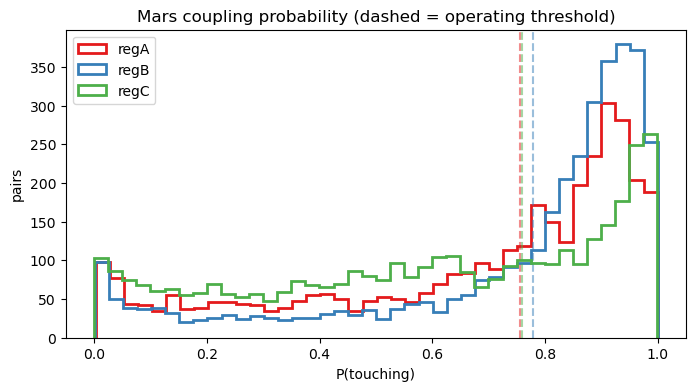

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for r, col in zip(REGIMES_, ['#e41a1c', '#377eb8', '#4daf4a']):
    p = MARS_OUT / f'mars_combined_{r}_predictions.parquet'
    if p.exists():
        d = pd.read_parquet(p)
        ax.hist(d.prob_touching, bins=40, histtype='step', lw=2, color=col, label=r)
        ax.axvline(OP_THR[r], color=col, ls='--', alpha=0.5)
ax.set_xlabel('P(touching)'); ax.set_ylabel('pairs')
ax.set_title('Mars coupling probability (dashed = operating threshold)'); ax.legend(); plt.show()

### Map: predicted coupling across Mars valley networks (regA)

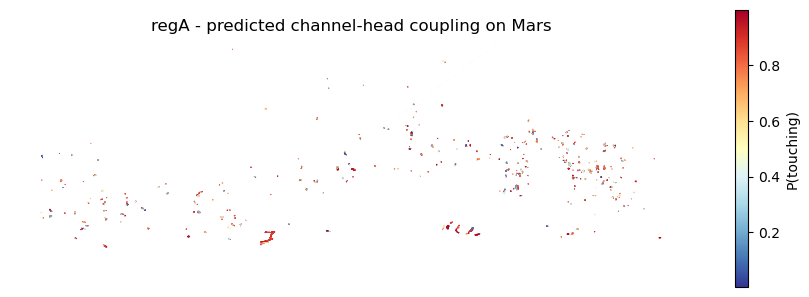

In [4]:
import geopandas as gpd
g = MARS_OUT / 'mars_combined_regA_predictions.gpkg'
if g.exists():
    gdf = gpd.read_file(g, layer='pairs')
    fig, ax = plt.subplots(figsize=(11, 6))
    gdf.plot(ax=ax, column='prob_touching', cmap='RdYlBu_r', linewidth=0.6,
             legend=True, legend_kwds={'label': 'P(touching)', 'shrink': 0.6})
    ax.set_title('regA - predicted channel-head coupling on Mars'); ax.set_aspect('equal'); ax.axis('off')
    plt.show()

Deep dive: `notebooks/regime/01_mars_inference.ipynb`.